In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from pathlib import Path
import warnings
from sklearn.exceptions import ConvergenceWarning
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

In [4]:
df = pd.read_csv('../Dataset/AmesHousing.csv')
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [5]:
df = df.drop(columns=['Order', 'PID'])

print(f"Shape after dropping IDs: {df.shape}")
print(f"Features: {df.shape[1] - 1}  |  Target: SalePrice")

Shape after dropping IDs: (2930, 80)
Features: 79  |  Target: SalePrice


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 80 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   MS SubClass      2930 non-null   int64  
 1   MS Zoning        2930 non-null   str    
 2   Lot Frontage     2440 non-null   float64
 3   Lot Area         2930 non-null   int64  
 4   Street           2930 non-null   str    
 5   Alley            198 non-null    str    
 6   Lot Shape        2930 non-null   str    
 7   Land Contour     2930 non-null   str    
 8   Utilities        2930 non-null   str    
 9   Lot Config       2930 non-null   str    
 10  Land Slope       2930 non-null   str    
 11  Neighborhood     2930 non-null   str    
 12  Condition 1      2930 non-null   str    
 13  Condition 2      2930 non-null   str    
 14  Bldg Type        2930 non-null   str    
 15  House Style      2930 non-null   str    
 16  Overall Qual     2930 non-null   int64  
 17  Overall Cond     2930 non

In [7]:
df.describe()

,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,2929.000000,2929.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,442.629566,49.722431,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,455.590839,169.168476,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,370.000000,0.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,734.000000,0.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1526.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


In [8]:
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)
print(f'Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')

Train: (1758, 79) | Val: (586, 79) | Test: (586, 79)


In [9]:
# Numeric columns
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

# Ordinal columns
ordinal_cols = [
    'Lot Shape',        # Reg > IR1 > IR2 > IR3 (regularity of lot)
    'Utilities',        # AllPub > NoSeWa > NoSewr > ELO
    'Land Slope',       # Gtl > Mod > Sev (gentleness of slope)
    'Exter Qual',       # Ex > Gd > TA > Fa > Po
    'Exter Cond',       # Ex > Gd > TA > Fa > Po
    'Bsmt Qual',        # Ex > Gd > TA > Fa > Po > NA
    'Bsmt Cond',        # Ex > Gd > TA > Fa > Po > NA
    'Bsmt Exposure',    # Gd > Av > Mn > No > NA
    'BsmtFin Type 1',   # GLQ > ALQ > BLQ > Rec > LwQ > Unf > NA
    'BsmtFin Type 2',   # GLQ > ALQ > BLQ > Rec > LwQ > Unf > NA
    'Heating QC',       # Ex > Gd > TA > Fa > Po
    'Electrical',       # SBrkr > FuseA > FuseF > FuseP > Mix
    'Kitchen Qual',     # Ex > Gd > TA > Fa > Po
    'Functional',       # Typ > Min1 > Min2 > Mod > Maj1 > Maj2 > Sev > Sal
    'Fireplace Qu',     # Ex > Gd > TA > Fa > Po > NA
    'Garage Finish',    # Fin > RFn > Unf > NA
    'Garage Qual',      # Ex > Gd > TA > Fa > Po > NA
    'Garage Cond',      # Ex > Gd > TA > Fa > Po > NA
    'Paved Drive',      # Y > P > N
    'Pool QC',          # Ex > Gd > TA > Fa > NA
    'Fence',            # GdPrv > MnPrv > GdWo > MnWw > NA
]

# Nominal columns
nominal_cols = [
    c for c in X_train.select_dtypes(include='object').columns
    if c not in ordinal_cols
]
print(f'Numeric cols:  {len(numeric_cols)}')
print(f'Ordinal cols:  {len(ordinal_cols)}')
print(f'Nominal cols:  {len(nominal_cols)}')

Numeric cols:  36
Ordinal cols:  21
Nominal cols:  22


C:\Users\saleh\AppData\Local\Temp\ipykernel_58464\1264565023.py:31: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  c for c in X_train.select_dtypes(include='object').columns


## Phase 2 — EDA & Feature Selection (Training Set Only)

All analysis below touches only `X_train` / `y_train` — no peeking at validation or test sets.

| Step | What | Method |
|------|------|--------|
| 1 | Missing value audit | null counts + % per column |
| 2 | Numeric features | Pearson r, redundancy (|r|>0.7) |
| 3 | Ordinal features | Spearman ρ (rank-safe, no equal-interval assumption) |
| 4 | Nominal features | Eta² (ANOVA) |
| 5 | All features | Mutual Information |
| 6 | Target distribution | Skewness check → log-transform decision |

In [10]:
# ── 1. Missing Value Audit ──────────────────────────────────────────────────────
n_train     = len(X_train)
null_counts = X_train.isnull().sum()
null_pct    = (null_counts / n_train * 100).round(2)

missing_df = (
    pd.DataFrame({'null_count': null_counts, 'null_pct': null_pct})
    .query('null_count > 0')
    .sort_values('null_pct', ascending=False)
)

HIGH_MISS_THRESHOLD = 40.0
high_miss_cols = missing_df[missing_df['null_pct'] > HIGH_MISS_THRESHOLD].index.tolist()

print(f"Columns with any missing values   : {len(missing_df)}")
print(f"Drop candidates (>{HIGH_MISS_THRESHOLD}% missing) : {high_miss_cols}\n")
print(missing_df.to_string())

Columns with any missing values   : 26
Drop candidates (>40.0% missing) : ['Pool QC', 'Misc Feature', 'Alley', 'Fence', 'Mas Vnr Type', 'Fireplace Qu']

                null_count  null_pct
Pool QC               1752     99.66
Misc Feature          1692     96.25
Alley                 1636     93.06
Fence                 1411     80.26
Mas Vnr Type          1055     60.01
Fireplace Qu           877     49.89
Lot Frontage           308     17.52
Garage Cond             99      5.63
Garage Yr Blt           99      5.63
Garage Finish           99      5.63
Garage Qual             99      5.63
Garage Type             98      5.57
Bsmt Exposure           44      2.50
Bsmt Cond               42      2.39
Bsmt Qual               42      2.39
BsmtFin Type 2          42      2.39
BsmtFin Type 1          42      2.39
Mas Vnr Area            12      0.68
BsmtFin SF 1             1      0.06
Bsmt Half Bath           1      0.06
Total Bsmt SF            1      0.06
Bsmt Full Bath           1      0

Numeric features ranked by |Pearson r|:

                 pearson_r  |pearson_r|  MI_score
Overall Qual      0.791238     0.791238  0.575757
Gr Liv Area       0.703896     0.703896  0.499618
Garage Cars       0.642291     0.642291  0.361606
Total Bsmt SF     0.641928     0.641928  0.385737
Garage Area       0.630587     0.630587  0.396956
1st Flr SF        0.623946     0.623946  0.351188
Year Built        0.543292     0.543292  0.365419
Full Bath         0.542791     0.542791  0.293844
Year Remod/Add    0.511051     0.511051  0.279342
Mas Vnr Area      0.507868     0.507868  0.153840
Garage Yr Blt     0.490619     0.490619  0.267226
TotRms AbvGrd     0.489907     0.489907  0.195409
Fireplaces        0.470092     0.470092  0.179517
BsmtFin SF 1      0.429570     0.429570  0.163477
Wood Deck SF      0.345771     0.345771  0.122353
Lot Frontage      0.328296     0.328296  0.210344
Bsmt Full Bath    0.293330     0.293330  0.056989
Half Bath         0.291909     0.291909  0.068818
Open Porc

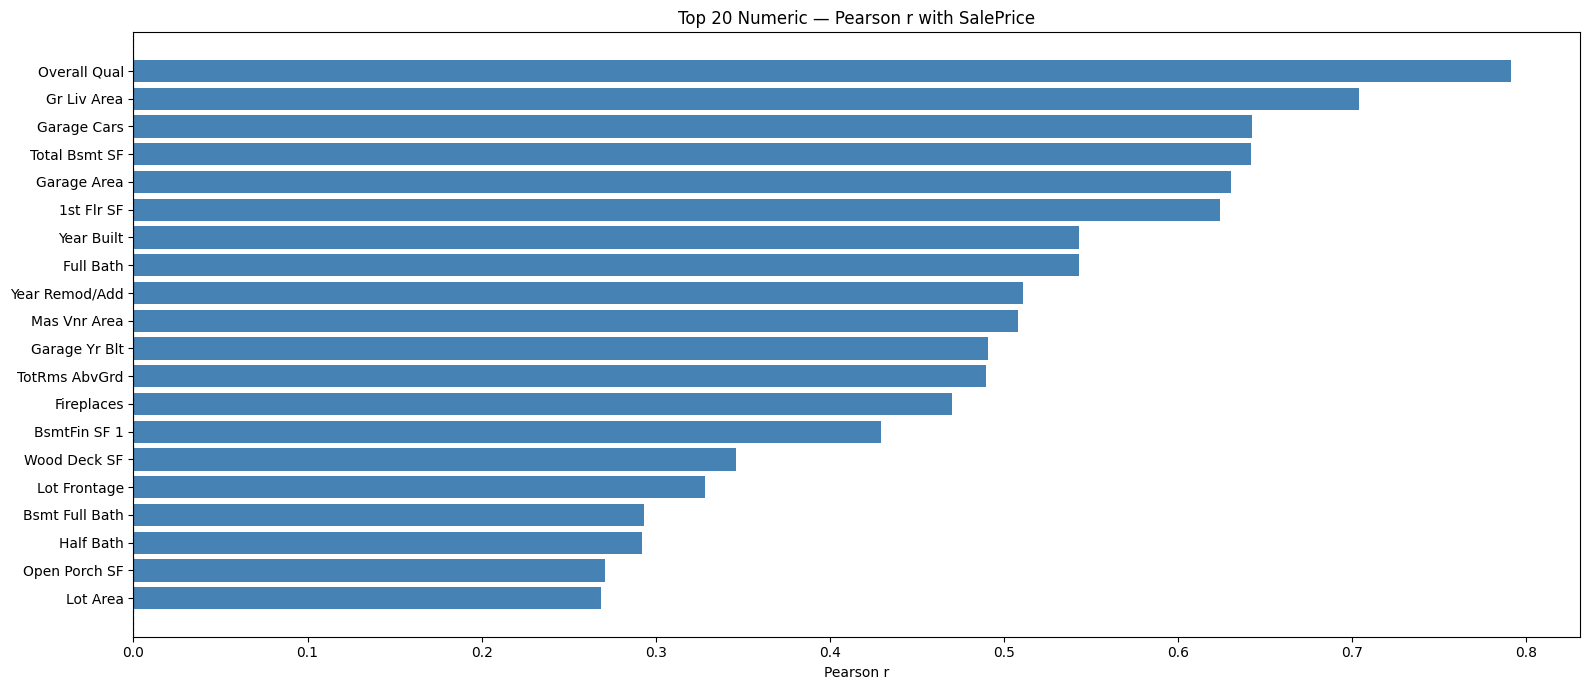

In [11]:
# ── 2. Numeric Feature Analysis — Pearson r & Mutual Information ───────────────
from sklearn.feature_selection import mutual_info_regression

# Median-fill NaNs for analysis only (medians from X_train — no leakage)
X_train_num = X_train[numeric_cols].fillna(X_train[numeric_cols].median())

# 2a. Pearson r with SalePrice
pearson_r   = X_train_num.corrwith(y_train).rename('pearson_r')
pearson_abs = pearson_r.abs().rename('|pearson_r|')

# 2b. Mutual Information — numeric features need no encoding
mi_scores = mutual_info_regression(X_train_num, y_train, random_state=42)
mi_series = pd.Series(mi_scores, index=numeric_cols, name='MI_score')

numeric_scores = (
    pd.concat([pearson_r, pearson_abs, mi_series], axis=1)
    .sort_values('|pearson_r|', ascending=False)
)
print("Numeric features ranked by |Pearson r|:\n")
print(numeric_scores.to_string())

# ── Visualisation ──────────────────────────────────────────────────────────────
TOP_N = 20
top = numeric_scores.head(TOP_N)

fig, axes = plt.subplots(1, 1, figsize=(16, 7))

# Signed Pearson r bar chart
colors = ['steelblue' if v >= 0 else 'tomato' for v in top['pearson_r'][::-1]]
axes.barh(top.index[::-1], top['pearson_r'][::-1], color=colors)
axes.axvline(0, color='black', linewidth=0.8, linestyle='--')
axes.set_title(f'Top {TOP_N} Numeric — Pearson r with SalePrice')
axes.set_xlabel('Pearson r')


plt.tight_layout()
plt.show()

Redundant numeric pairs (|r| > 0.7): 4

    feature_a     feature_b  inter_corr          keep drop_candidate
  Garage Cars   Garage Area       0.890   Garage Cars    Garage Area
Total Bsmt SF    1st Flr SF       0.828 Total Bsmt SF     1st Flr SF
  Gr Liv Area TotRms AbvGrd       0.816   Gr Liv Area  TotRms AbvGrd
   Year Built Garage Yr Blt       0.774    Year Built  Garage Yr Blt


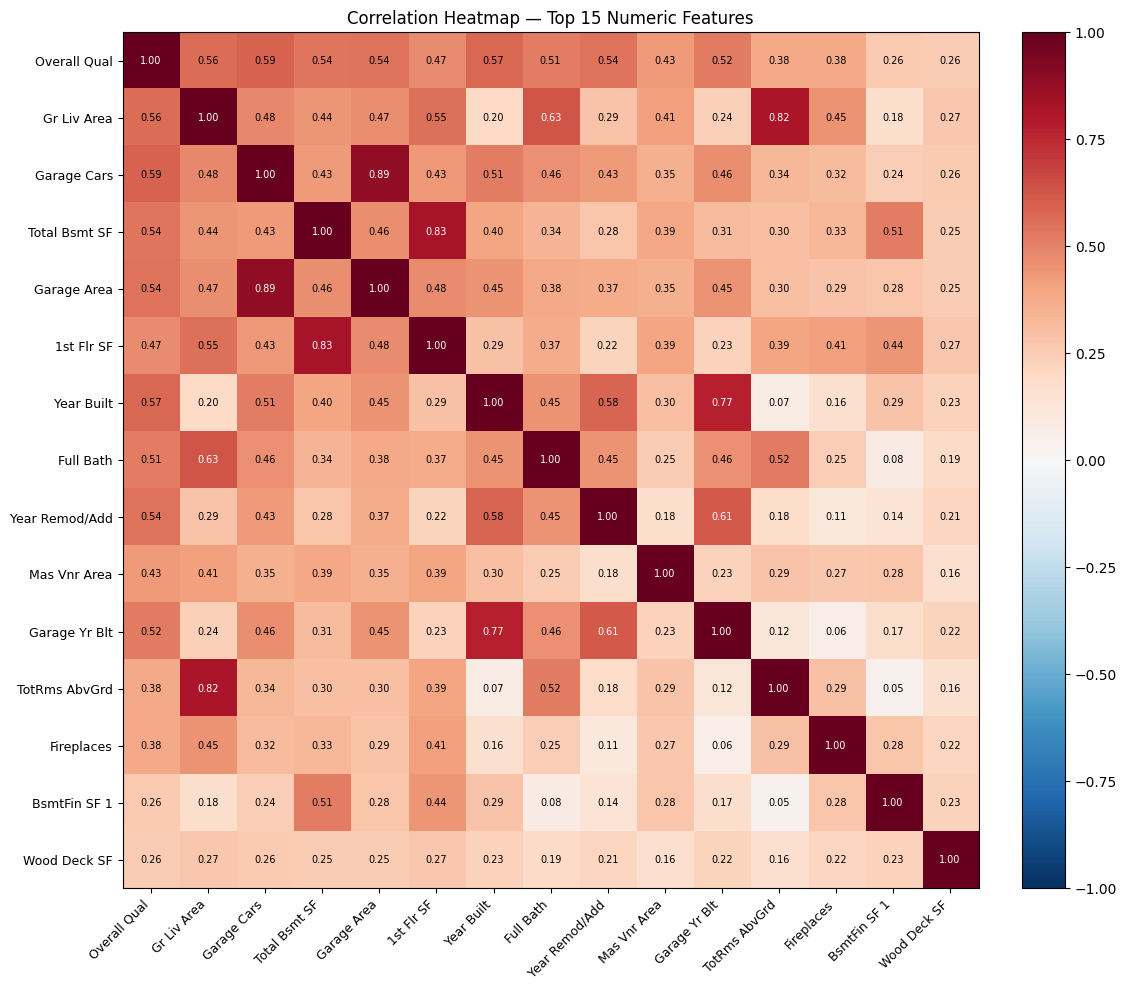

In [12]:
# 2c. Redundant feature pairs (|inter-corr| > 0.7) + correlation heatmap
REDUNDANCY_THRESHOLD = 0.7
corr_matrix = X_train_num.corr()
upper = corr_matrix.abs().where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

redundant_pairs = []
for col in upper.columns:
    for idx in upper.index:
        val = upper.loc[idx, col]
        if pd.notna(val) and val > REDUNDANCY_THRESHOLD:
            r_col = pearson_abs.get(col, 0)
            r_idx = pearson_abs.get(idx, 0)
            keep = col if r_col >= r_idx else idx
            drop = idx if keep == col else col
            redundant_pairs.append({
                'feature_a':      idx,
                'feature_b':      col,
                'inter_corr':     round(val, 3),
                'keep':           keep,
                'drop_candidate': drop
            })

redundant_df = pd.DataFrame(redundant_pairs).sort_values('inter_corr', ascending=False)
print(f"Redundant numeric pairs (|r| > {REDUNDANCY_THRESHOLD}): {len(redundant_df)}\n")
print(redundant_df.to_string(index=False))

# ── Heatmap of top 15 numeric features ────────────────────────────────────────
top15 = numeric_scores.head(15).index.tolist()
hm    = corr_matrix.loc[top15, top15]

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(hm, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_xticks(range(len(top15))); ax.set_xticklabels(top15, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(top15))); ax.set_yticklabels(top15, fontsize=9)
for i in range(len(top15)):
    for j in range(len(top15)):
        v = hm.iloc[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=7,
                color='white' if abs(v) > 0.6 else 'black')
ax.set_title('Correlation Heatmap — Top 15 Numeric Features')
plt.tight_layout()
plt.show()

Ordinal features — Eta² with SalePrice:

       feature  eta_squared  n_categories
     Bsmt Qual       0.5038             6
    Exter Qual       0.5008             4
  Kitchen Qual       0.4781             4
  Fireplace Qu       0.3169             6
 Garage Finish       0.2855             4
BsmtFin Type 1       0.2170             7
    Heating QC       0.1940             5
 Bsmt Exposure       0.1829             5
   Garage Qual       0.1002             6
     Lot Shape       0.0943             4
   Garage Cond       0.0924             6
   Paved Drive       0.0778             3
    Electrical       0.0602             5
     Bsmt Cond       0.0480             6
         Fence       0.0368             5
BsmtFin Type 2       0.0326             7
    Exter Cond       0.0236             5
    Functional       0.0180             8
       Pool QC       0.0131             4
    Land Slope       0.0099             3
     Utilities       0.0006             3


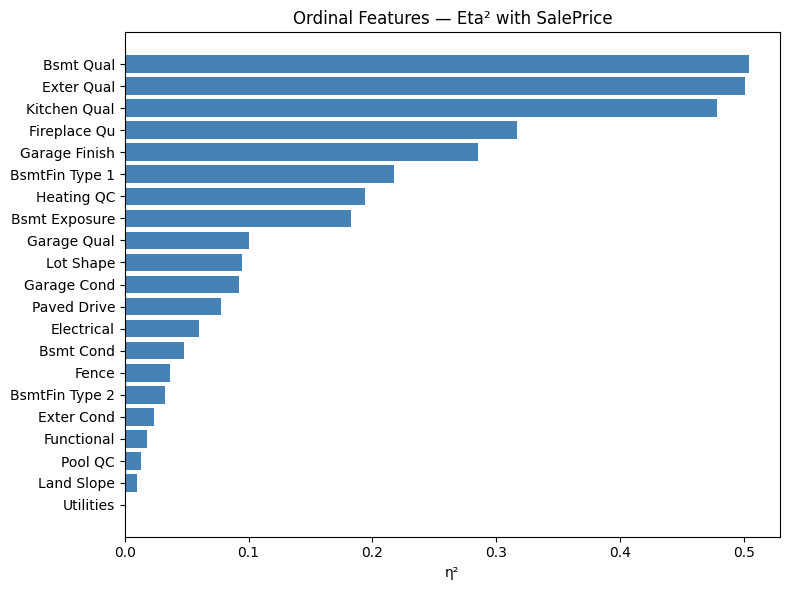

<Figure size 640x480 with 0 Axes>

In [13]:
# ── 3. Ordinal Feature Analysis — Eta² ────────────────────────────────────────
# Eta² groups on raw category strings — no encoding needed.

def eta_squared(col_series, target):
    """η² = SS_between / SS_total — fraction of target variance explained by groups."""
    grand_mean = target.mean()
    ss_total   = ((target - grand_mean) ** 2).sum()
    ss_between = sum(
        len(grp) * (grp.mean() - grand_mean) ** 2
        for grp in (target[col_series == cat] for cat in col_series.unique())
    )
    return ss_between / ss_total if ss_total > 0 else 0.0

ordinal_results = []
for col in ordinal_cols:
    col_filled = X_train[col].fillna('NA')
    ordinal_results.append({
        'feature':      col,
        'eta_squared':  round(eta_squared(col_filled, y_train), 4),
        'n_categories': col_filled.nunique()
    })

ordinal_scores_df = pd.DataFrame(ordinal_results).sort_values('eta_squared', ascending=False)
print("Ordinal features — Eta² with SalePrice:\n")
print(ordinal_scores_df.to_string(index=False))

# ── Bar chart ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(ordinal_scores_df['feature'][::-1], ordinal_scores_df['eta_squared'][::-1], color='steelblue')
ax.set_title('Ordinal Features — Eta² with SalePrice')
ax.set_xlabel('η²')
plt.tight_layout()
plt.show()

plt.suptitle('Top 6 Ordinal Features vs SalePrice (sorted by median)', fontsize=13)
plt.tight_layout()
plt.show()

Nominal features — Eta² with SalePrice:

       feature  eta_squared  n_categories
  Neighborhood       0.5701            28
    Foundation       0.2604             6
   Garage Type       0.2465             7
  Mas Vnr Type       0.1790             5
  Exterior 1st       0.1529            15
Sale Condition       0.1475             6
     Sale Type       0.1420             9
  Exterior 2nd       0.1407            15
     MS Zoning       0.1203             6
   House Style       0.0784             8
    Roof Style       0.0742             6
   Central Air       0.0704             2
   Condition 1       0.0509             9
  Land Contour       0.0475             4
     Bldg Type       0.0313             5
         Alley       0.0257             3
     Roof Matl       0.0251             6
    Lot Config       0.0235             5
   Condition 2       0.0227             6
       Heating       0.0099             6
  Misc Feature       0.0039             5
        Street       0.0011        

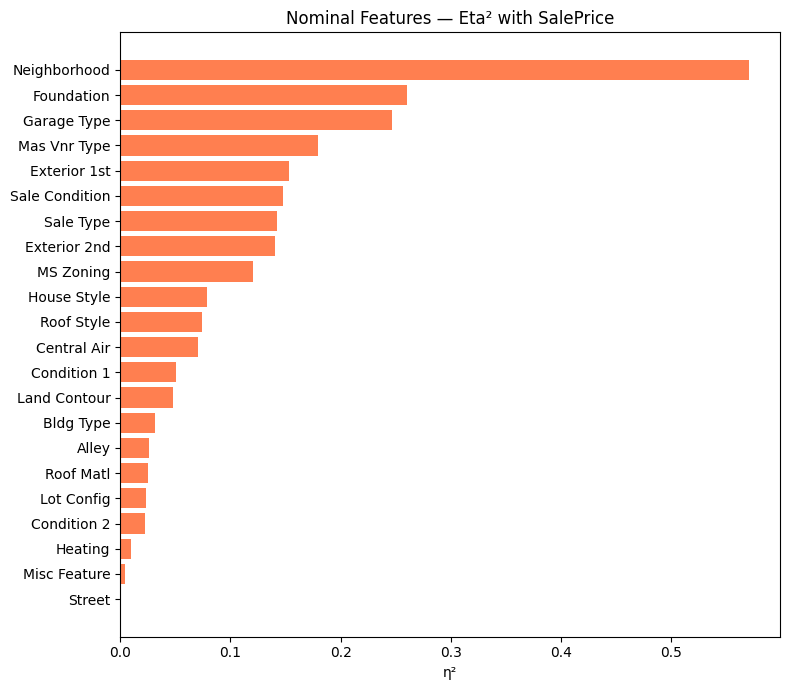

<Figure size 640x480 with 0 Axes>

In [14]:
# ── 4. Nominal Feature Analysis — Eta² ────────────────────────────────────────
# Reuses eta_squared() defined above — no encoding needed.

nominal_results = []
for col in nominal_cols:
    col_filled = X_train[col].fillna('NA')
    nominal_results.append({
        'feature':      col,
        'eta_squared':  round(eta_squared(col_filled, y_train), 4),
        'n_categories': col_filled.nunique()
    })

nominal_scores_df = pd.DataFrame(nominal_results).sort_values('eta_squared', ascending=False)
print("Nominal features — Eta² with SalePrice:\n")
print(nominal_scores_df.to_string(index=False))

# ── Bar chart ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(nominal_scores_df['feature'][::-1], nominal_scores_df['eta_squared'][::-1], color='coral')
ax.set_title('Nominal Features — Eta² with SalePrice')
ax.set_xlabel('η²')
plt.tight_layout()
plt.show()

plt.suptitle('Top 6 Nominal Features vs SalePrice (sorted by median)', fontsize=13)
plt.tight_layout()
plt.show()

All features ranked by Mutual Information with SalePrice:

Overall Qual       5.757573e-01
Neighborhood       5.299110e-01
Gr Liv Area        4.996182e-01
Garage Area        3.969560e-01
Total Bsmt SF      3.857372e-01
Year Built         3.654190e-01
Garage Cars        3.616064e-01
Bsmt Qual          3.524624e-01
1st Flr SF         3.511880e-01
Kitchen Qual       3.210769e-01
Exter Qual         3.005516e-01
Full Bath          2.938445e-01
Year Remod/Add     2.793422e-01
MS SubClass        2.763272e-01
Garage Yr Blt      2.672262e-01
Garage Finish      2.577244e-01
Garage Type        2.233478e-01
Lot Frontage       2.103442e-01
Fireplace Qu       2.090054e-01
Foundation         2.088631e-01
TotRms AbvGrd      1.954093e-01
2nd Flr SF         1.928700e-01
Fireplaces         1.795173e-01
BsmtFin Type 1     1.791625e-01
Open Porch SF      1.701094e-01
BsmtFin SF 1       1.634769e-01
Lot Area           1.540802e-01
Mas Vnr Area       1.538396e-01
Exterior 1st       1.456849e-01
Heating QC   

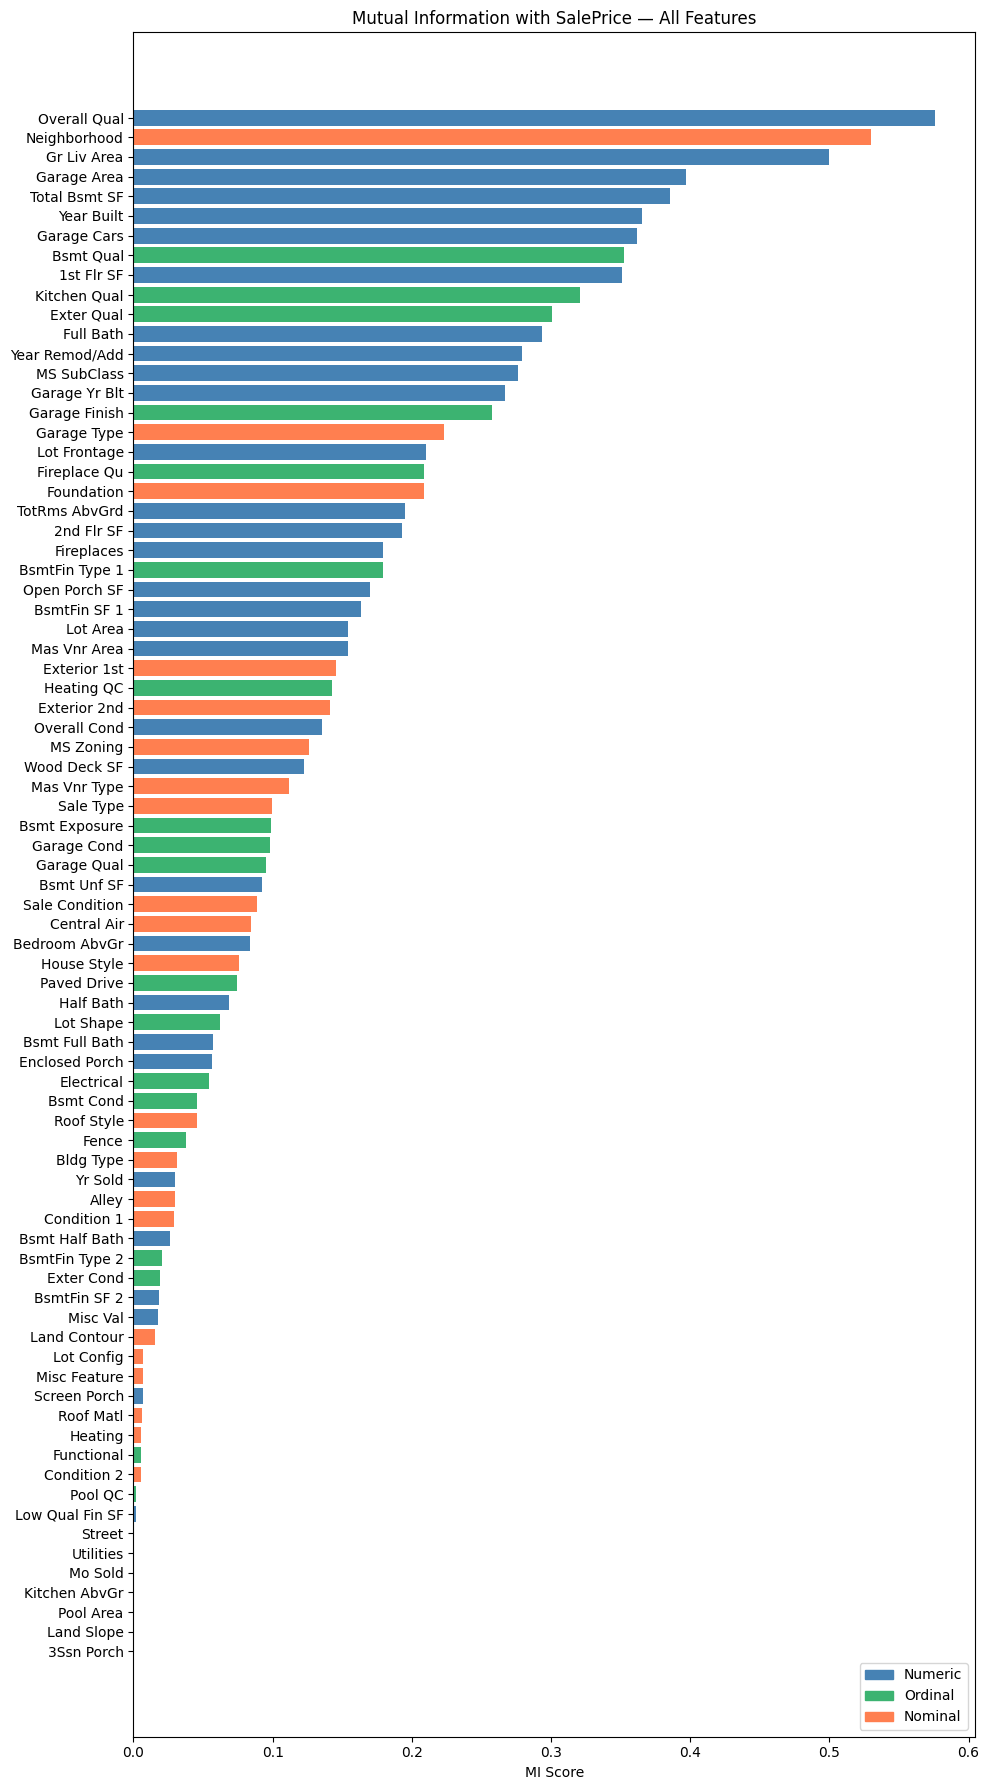

In [15]:
# ── 5. Mutual Information — All Features ──────────────────────────────────────
# Categorical columns get integer codes via .cat.codes (analysis only — not the
# pipeline encoding that comes in a later phase).

all_cols = numeric_cols + ordinal_cols + nominal_cols

mi_parts = []
discrete_mask = []

for col in all_cols:
    if col in numeric_cols:
        s = X_train[col].fillna(X_train[col].median())
        discrete_mask.append(False)
    else:
        s = X_train[col].fillna('NA').astype('category').cat.codes
        discrete_mask.append(True)
    mi_parts.append(s.rename(col))

X_all = pd.concat(mi_parts, axis=1)

mi_all = mutual_info_regression(X_all, y_train,
                                discrete_features=discrete_mask,
                                random_state=42)
mi_all_series = (
    pd.Series(mi_all, index=all_cols, name='MI_score')
    .sort_values(ascending=False)
)

print("All features ranked by Mutual Information with SalePrice:\n")
print(mi_all_series.to_string())

# ── Visualisation ──────────────────────────────────────────────────────────────
# Color bars by feature type
type_color = {col: 'steelblue' for col in numeric_cols}
type_color.update({col: 'mediumseagreen' for col in ordinal_cols})
type_color.update({col: 'coral'          for col in nominal_cols})

bar_colors = [type_color[c] for c in mi_all_series.index[::-1]]

fig, ax = plt.subplots(figsize=(10, 18))
ax.barh(mi_all_series.index[::-1], mi_all_series.values[::-1], color=bar_colors)
ax.set_title('Mutual Information with SalePrice — All Features')
ax.set_xlabel('MI Score')

# Legend
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='steelblue',      label='Numeric'),
    Patch(color='mediumseagreen', label='Ordinal'),
    Patch(color='coral',          label='Nominal'),
], loc='lower right')

plt.tight_layout()
plt.show()

SalePrice skewness  (raw)   : 1.7552
SalePrice skewness  (log1p) : -0.1112

→ log1p reduces skew: apply log1p(SalePrice) during modelling.


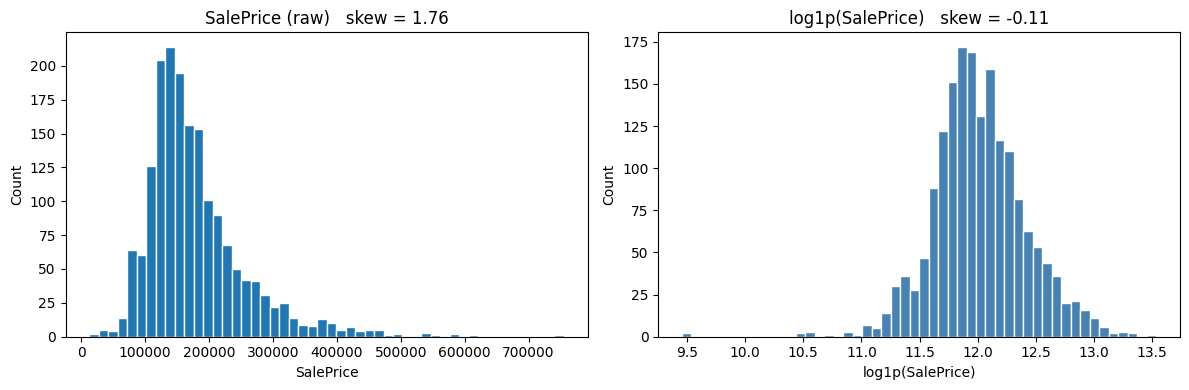

In [16]:
# ── 6. Target Distribution — Skewness & Log-Transform Decision ─────────────────
from scipy.stats import skew

raw_skew = skew(y_train)
log_skew = skew(np.log1p(y_train))

print(f"SalePrice skewness  (raw)   : {raw_skew:.4f}")
print(f"SalePrice skewness  (log1p) : {log_skew:.4f}")
print()
if abs(log_skew) < abs(raw_skew):
    print("→ log1p reduces skew: apply log1p(SalePrice) during modelling.")
else:
    print("→ log1p does not help: keep raw SalePrice.")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y_train, bins=50, edgecolor='white')
axes[0].set_title(f'SalePrice (raw)   skew = {raw_skew:.2f}')
axes[0].set_xlabel('SalePrice')
axes[0].set_ylabel('Count')

axes[1].hist(np.log1p(y_train), bins=50, edgecolor='white', color='steelblue')
axes[1].set_title(f'log1p(SalePrice)   skew = {log_skew:.2f}')
axes[1].set_xlabel('log1p(SalePrice)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [17]:
# ── 7. Feature Selection — Keep the 12 Chosen Features ────────────────────────
# Picked from MI + Eta² rankings, with redundancy filter (|r| > 0.7) applied.
# Dropped: Garage Cars (r=0.89 w/ Garage Area), 1st Flr SF (r=0.83 w/ Total Bsmt SF),
# TotRms AbvGrd (r=0.82 w/ Gr Liv Area), Garage Yr Blt (r=0.77 w/ Year Built), and
# all high-missing columns (Pool QC, Misc Feature, Alley, Fence, Mas Vnr Type).

selected_numeric = [
    'Overall Qual', 'Gr Liv Area', 'Garage Area', 'Total Bsmt SF',
    'Year Built', 'Full Bath', 'Mas Vnr Area',
]
selected_ordinal = ['Bsmt Qual', 'Exter Qual', 'Kitchen Qual', 'Fireplace Qu']
selected_nominal = ['Neighborhood']

SELECTED_FEATURES = selected_numeric + selected_ordinal + selected_nominal
assert len(SELECTED_FEATURES) == 12, "Expected exactly 12 features"

# Slice all three splits to keep only the chosen columns
X_train = X_train[SELECTED_FEATURES]
X_val   = X_val[SELECTED_FEATURES]
X_test  = X_test[SELECTED_FEATURES]

# Update the column-type lists so downstream phases (encoding, scaling) use them
numeric_cols = selected_numeric
ordinal_cols = selected_ordinal
nominal_cols = selected_nominal

print(f"Selected features ({len(SELECTED_FEATURES)}):")
print(f"  Numeric ({len(numeric_cols)}) : {numeric_cols}")
print(f"  Ordinal ({len(ordinal_cols)}) : {ordinal_cols}")
print(f"  Nominal ({len(nominal_cols)}) : {nominal_cols}")
print()
print(f"Shapes after selection — Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")


Selected features (12):
  Numeric (7) : ['Overall Qual', 'Gr Liv Area', 'Garage Area', 'Total Bsmt SF', 'Year Built', 'Full Bath', 'Mas Vnr Area']
  Ordinal (4) : ['Bsmt Qual', 'Exter Qual', 'Kitchen Qual', 'Fireplace Qu']
  Nominal (1) : ['Neighborhood']

Shapes after selection — Train: (1758, 12) | Val: (586, 12) | Test: (586, 12)


# ── Phase 3 · Preprocessing Pipeline (ColumnTransformer) ──────────────────────

In [18]:
# Explicit category order — worst → best. 'NA' = no basement / no fireplace.
qual_order = ['NA', 'Po', 'Fa', 'TA', 'Gd', 'Ex']
ordinal_categories = [qual_order] * len(ordinal_cols)   # same order for all 4

numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

ordinal_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='NA')),
    ('encoder', OrdinalEncoder(
        categories=ordinal_categories,
        handle_unknown='use_encoded_value',
        unknown_value=-1,
    )),
    ('scaler',  StandardScaler()),
])

nominal_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

In [19]:
preprocessor = ColumnTransformer([
    ('num', numeric_pipe, numeric_cols),
    ('ord', ordinal_pipe, ordinal_cols),
    ('nom', nominal_pipe, nominal_cols),
], remainder='drop')

# Fit on TRAIN ONLY — then transform all three splits
X_train_prep = preprocessor.fit_transform(X_train)
X_val_prep   = preprocessor.transform(X_val)
X_test_prep  = preprocessor.transform(X_test)

feature_names_out = preprocessor.get_feature_names_out()
print(f"Train: {X_train_prep.shape} | Val: {X_val_prep.shape} | Test: {X_test_prep.shape}")
print(f"Output features: {len(feature_names_out)}  (7 numeric + 4 ordinal + {X_train_prep.shape[1] - 11} one-hot)")

Train: (1758, 39) | Val: (586, 39) | Test: (586, 39)
Output features: 39  (7 numeric + 4 ordinal + 28 one-hot)


## Phase 4 — Model Selection & Pipelines

Five models, each with 5-fold CV and the best version persisted to `../models/`:

1. **Lasso** (L1 — built-in feature shrinkage)
2. **Ridge** (L2 — stable on correlated features)
3. **ElasticNet** (L1 + L2 blend)
4. **Random Forest** (non-linear, handles interactions)
5. **XGBoost** (gradient boosting — typically the winner)

Every model is wrapped in the Phase 3 `preprocessor` so CV folds re-fit imputers/encoders/scaler on each training fold → zero leakage. Target is log-transformed via `TransformedTargetRegressor` so errors are reported back in dollars.

---
### Part 1 — Lasso


In [41]:
def eval_pipeline(model, X_val, y_val, name):
    """Evaluate a fitted model on train and validation sets."""
    y_pred_train = model.predict(X_train)
    y_pred_val   = model.predict(X_val)

    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    val_rmse   = np.sqrt(mean_squared_error(y_val,   y_pred_val))
    train_mae  = mean_absolute_error(y_train, y_pred_train)
    val_mae    = mean_absolute_error(y_val,   y_pred_val)
    train_r2   = r2_score(y_train, y_pred_train)
    val_r2     = r2_score(y_val,   y_pred_val)

    print(f"{'─' * 50}")
    print(f"  {name}")
    print(f"{'─' * 50}")
    print(f"  {'Metric':<10} {'Train':>12} {'Val':>12}")
    print(f"  {'RMSE':<10} {'${:,.0f}'.format(train_rmse):>12} {'${:,.0f}'.format(val_rmse):>12}")
    print(f"  {'MAE':<10} {'${:,.0f}'.format(train_mae):>12} {'${:,.0f}'.format(val_mae):>12}")
    print(f"  {'R²':<10} {train_r2:>12.4f} {val_r2:>12.4f}")
    print(f"{'─' * 50}")


In [20]:
MODELS_DIR = Path('../models')
MODELS_DIR.mkdir(exist_ok=True)

# preprocessor + Lasso, with log1p(y) inside TransformedTargetRegressor
lasso_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Lasso(max_iter=20000, random_state=42)),
])

lasso_estimator = TransformedTargetRegressor(
    regressor=lasso_pipe,
    func=np.log1p,
    inverse_func=np.expm1,
)

# 5-fold CV grid search over alpha (log scale)
param_grid = {'regressor__model__alpha': np.logspace(-4, 1, 30)}
cv = KFold(n_splits=5, shuffle=True, random_state=42)

lasso_search = GridSearchCV(
    estimator=lasso_estimator,
    param_grid=param_grid,
    cv=cv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    refit=True,
)

with warnings.catch_warnings():
    warnings.simplefilter('ignore', ConvergenceWarning)
    lasso_search.fit(X_train, y_train)

best_alpha = lasso_search.best_params_['regressor__model__alpha']
cv_rmse    = -lasso_search.best_score_

print(f"Best α         : {best_alpha:.6f}")
print(f"CV RMSE (5-fold): ${cv_rmse:,.0f}")


Best α         : 0.000100
CV RMSE (5-fold): $33,804


In [21]:
# ── Evaluate on validation set & persist the best Lasso ───────────────────────
import joblib
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

best_lasso = lasso_search.best_estimator_

y_pred_val = best_lasso.predict(X_val)
val_rmse   = np.sqrt(mean_squared_error(y_val, y_pred_val))
val_mae    = mean_absolute_error(y_val, y_pred_val)
val_r2     = r2_score(y_val, y_pred_val)

print(f"Validation — Lasso (α = {best_alpha:.4f})")
print(f"  RMSE : ${val_rmse:,.0f}")
print(f"  MAE  : ${val_mae:,.0f}")
print(f"  R²   :  {val_r2:.4f}")

lasso_path = MODELS_DIR / 'lasso_best.joblib'
joblib.dump({
    'model':       best_lasso,
    'best_params': lasso_search.best_params_,
    'cv_rmse':     cv_rmse,
    'val_rmse':    val_rmse,
    'val_mae':     val_mae,
    'val_r2':      val_r2,
    'features':    SELECTED_FEATURES,
}, lasso_path)

print(f"\nSaved → {lasso_path.resolve()}")


Validation — Lasso (α = 0.0001)
  RMSE : $59,516
  MAE  : $19,950
  R²   :  0.4877

Saved → C:\Users\saleh\OneDrive\Desktop\AI Real Estate Agent\models\lasso_best.joblib


### Part 2 — Ridge


In [22]:
# ── Phase 4 · Part 2 — Ridge (5-fold CV) ──────────────────────────────────────
from sklearn.linear_model import Ridge

ridge_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge(random_state=42)),
])

ridge_estimator = TransformedTargetRegressor(
    regressor=ridge_pipe,
    func=np.log1p,
    inverse_func=np.expm1,
)

# Ridge tolerates wider alphas than Lasso (L2 never zeroes coefficients)
param_grid = {'regressor__model__alpha': np.logspace(-3, 3, 30)}

ridge_search = GridSearchCV(
    estimator=ridge_estimator,
    param_grid=param_grid,
    cv=cv,                               # same KFold object from Part 1
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    refit=True,
)

ridge_search.fit(X_train, y_train)

best_alpha_r = ridge_search.best_params_['regressor__model__alpha']
cv_rmse_r    = -ridge_search.best_score_

print(f"Best α         : {best_alpha_r:.6f}")
print(f"CV RMSE (5-fold): ${cv_rmse_r:,.0f}")


Best α         : 0.001000
CV RMSE (5-fold): $33,628


In [23]:
# ── Evaluate on validation set & persist the best Ridge ───────────────────────
best_ridge = ridge_search.best_estimator_

y_pred_val = best_ridge.predict(X_val)
val_rmse_r = np.sqrt(mean_squared_error(y_val, y_pred_val))
val_mae_r  = mean_absolute_error(y_val, y_pred_val)
val_r2_r   = r2_score(y_val, y_pred_val)

print(f"Validation — Ridge (α = {best_alpha_r:.4f})")
print(f"  RMSE : ${val_rmse_r:,.0f}")
print(f"  MAE  : ${val_mae_r:,.0f}")
print(f"  R²   :  {val_r2_r:.4f}")

ridge_path = MODELS_DIR / 'ridge_best.joblib'
joblib.dump({
    'model':       best_ridge,
    'best_params': ridge_search.best_params_,
    'cv_rmse':     cv_rmse_r,
    'val_rmse':    val_rmse_r,
    'val_mae':     val_mae_r,
    'val_r2':      val_r2_r,
    'features':    SELECTED_FEATURES,
}, ridge_path)

print(f"\nSaved → {ridge_path.resolve()}")


Validation — Ridge (α = 0.0010)
  RMSE : $58,120
  MAE  : $19,910
  R²   :  0.5114

Saved → C:\Users\saleh\OneDrive\Desktop\AI Real Estate Agent\models\ridge_best.joblib


### Part 3 — ElasticNet

In [24]:
# ── Phase 4 · Part 3 — ElasticNet (5-fold CV) ─────────────────────────────────
from sklearn.linear_model import ElasticNet

elastic_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', ElasticNet(max_iter=20000, random_state=42)),
])

elastic_estimator = TransformedTargetRegressor(
    regressor=elastic_pipe,
    func=np.log1p,
    inverse_func=np.expm1,
)

# Grid: alpha (overall strength) × l1_ratio (L1 vs L2 mix; 0 = Ridge, 1 = Lasso)
param_grid = {
    'regressor__model__alpha':    np.logspace(-4, 1, 20),
    'regressor__model__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99],
}

elastic_search = GridSearchCV(
    estimator=elastic_estimator,
    param_grid=param_grid,
    cv=cv,                               # same 5-fold KFold from Part 1
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    refit=True,
)

with warnings.catch_warnings():
    warnings.simplefilter('ignore', ConvergenceWarning)
    elastic_search.fit(X_train, y_train)

best_alpha_e    = elastic_search.best_params_['regressor__model__alpha']
best_l1_ratio_e = elastic_search.best_params_['regressor__model__l1_ratio']
cv_rmse_e       = -elastic_search.best_score_

print(f"Best α          : {best_alpha_e:.6f}")
print(f"Best l1_ratio   : {best_l1_ratio_e}")
print(f"CV RMSE (5-fold): ${cv_rmse_e:,.0f}")


Best α          : 0.000100
Best l1_ratio   : 0.1
CV RMSE (5-fold): $33,665


In [30]:
# ── Evaluate on validation set & persist the best ElasticNet ──────────────────
best_elastic = elastic_search.best_estimator_

y_pred_val = best_elastic.predict(X_val)
val_rmse_e = np.sqrt(mean_squared_error(y_val, y_pred_val))
val_mae_e  = mean_absolute_error(y_val, y_pred_val)
val_r2_e   = r2_score(y_val, y_pred_val)

print(f"Validation — ElasticNet (α = {best_alpha_e:.4f}, l1_ratio = {best_l1_ratio_e})")
print(f"  RMSE : ${val_rmse_e:,.0f}")
print(f"  MAE  : ${val_mae_e:,.0f}")
print(f"  R²   :  {val_r2_e:.4f}")

elastic_path = MODELS_DIR / 'elasticnet_best.joblib'
joblib.dump({
    'model':       best_elastic,
    'best_params': elastic_search.best_params_,
    'cv_rmse':     cv_rmse_e,
    'val_rmse':    val_rmse_e,
    'val_mae':     val_mae_e,
    'val_r2':      val_r2_e,
    'features':    SELECTED_FEATURES,
}, elastic_path)

print(f"\nSaved → {elastic_path.resolve()}")


Validation — ElasticNet (α = 0.0001, l1_ratio = 0.1)
  RMSE : $58,392
  MAE  : $19,916
  R²   :  0.5068

Saved → C:\Users\saleh\OneDrive\Desktop\AI Real Estate Agent\models\elasticnet_best.joblib


### Part 4 — Random Forest

In [26]:
# ── Phase 4 · Part 4 — Random Forest (5-fold CV) ──────────────────────────────
from sklearn.ensemble import RandomForestRegressor

rf_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        random_state=42,
        n_jobs=1,                        # let the search parallelize the outer loop
    )),
])

rf_estimator = TransformedTargetRegressor(
    regressor=rf_pipe,
    func=np.log1p,
    inverse_func=np.expm1,
)

# Randomised search — wider coverage than a small grid in the same compute budget
param_dist = {
    'regressor__model__n_estimators'     : randint(300, 1000),
    'regressor__model__max_depth'        : [None, 8, 12, 16, 20, 28],
    'regressor__model__min_samples_split': randint(2, 12),
    'regressor__model__min_samples_leaf' : randint(1, 6),
    'regressor__model__max_features'     : ['sqrt', 'log2', 0.5, 0.7, 1.0],
}

rf_search = RandomizedSearchCV(
    estimator=rf_estimator,
    param_distributions=param_dist,
    n_iter=40,
    cv=cv,                               # same 5-fold KFold from Part 1
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    refit=True,
    random_state=42,
    verbose=1,
)

rf_search.fit(X_train, y_train)

best_params_rf = rf_search.best_params_
cv_rmse_rf     = -rf_search.best_score_

print(f"\nCV RMSE (5-fold): ${cv_rmse_rf:,.0f}")
print("Best hyperparameters:")
for k, v in best_params_rf.items():
    name = k.replace('regressor__model__', '')
    print(f"  {name:<20}: {v}")


Fitting 5 folds for each of 40 candidates, totalling 200 fits

CV RMSE (5-fold): $28,663
Best hyperparameters:
  max_depth           : 20
  max_features        : sqrt
  min_samples_leaf    : 1
  min_samples_split   : 2
  n_estimators        : 301


In [31]:
# ── Evaluate on validation set & persist the best Random Forest ───────────────
best_rf = rf_search.best_estimator_

y_pred_val = best_rf.predict(X_val)
val_rmse_rf = np.sqrt(mean_squared_error(y_val, y_pred_val))
val_mae_rf  = mean_absolute_error(y_val, y_pred_val)
val_r2_rf   = r2_score(y_val, y_pred_val)

print("Validation — Random Forest")
print(f"  RMSE : ${val_rmse_rf:,.0f}")
print(f"  MAE  : ${val_mae_rf:,.0f}")
print(f"  R²   :  {val_r2_rf:.4f}")

rf_path = MODELS_DIR / 'random_forest_best.joblib'
joblib.dump({
    'model':       best_rf,
    'best_params': best_params_rf,
    'cv_rmse':     cv_rmse_rf,
    'val_rmse':    val_rmse_rf,
    'val_mae':     val_mae_rf,
    'val_r2':      val_r2_rf,
    'features':    SELECTED_FEATURES,
}, rf_path)

print(f"\nSaved → {rf_path.resolve()}")


Validation — Random Forest
  RMSE : $28,600
  MAE  : $17,185
  R²   :  0.8817

Saved → C:\Users\saleh\OneDrive\Desktop\AI Real Estate Agent\models\random_forest_best.joblib


### Part 5 — XGBoost


In [28]:
# ── Phase 4 · Part 5 — XGBoost (5-fold CV) ────────────────────────────────────

xgb_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        objective='reg:squarederror',
        tree_method='hist',
        random_state=42,
        n_jobs=1,                        # let RandomizedSearchCV parallelize outer
    )),
])

xgb_estimator = TransformedTargetRegressor(
    regressor=xgb_pipe,
    func=np.log1p,
    inverse_func=np.expm1,
)

# Randomised search — wider coverage than a small grid in the same budget
param_dist = {
    'regressor__model__n_estimators'    : randint(300, 1200),
    'regressor__model__max_depth'       : randint(3, 9),
    'regressor__model__learning_rate'   : uniform(0.02, 0.13),   # 0.02 – 0.15
    'regressor__model__subsample'       : uniform(0.7, 0.3),     # 0.7 – 1.0
    'regressor__model__colsample_bytree': uniform(0.7, 0.3),     # 0.7 – 1.0
    'regressor__model__min_child_weight': randint(1, 8),
    'regressor__model__reg_alpha'       : uniform(0.0, 1.0),
    'regressor__model__reg_lambda'      : uniform(0.5, 2.0),
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_estimator,
    param_distributions=param_dist,
    n_iter=50,
    cv=cv,                               # same 5-fold KFold from Part 1
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    refit=True,
    random_state=42,
    verbose=1,
)

xgb_search.fit(X_train, y_train)

best_params_x = xgb_search.best_params_
cv_rmse_x     = -xgb_search.best_score_

print(f"\nBest CV RMSE (5-fold): ${cv_rmse_x:,.0f}")
print("Best hyperparameters:")
for k, v in best_params_x.items():
    name = k.replace('regressor__model__', '')
    print(f"  {name:<20}: {v}")


Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best CV RMSE (5-fold): $26,848
Best hyperparameters:
  colsample_bytree    : 0.7495800817189007
  learning_rate       : 0.02203273287635521
  max_depth           : 3
  min_child_weight    : 1
  n_estimators        : 947
  reg_alpha           : 0.005522117123602399
  reg_lambda          : 2.1309228569096685
  subsample           : 0.9120572031542851


In [42]:
# ── Evaluate on validation set & persist the best XGBoost ─────────────────────
best_xgb = xgb_search.best_estimator_

y_pred_val = best_xgb.predict(X_val)
val_rmse_x = np.sqrt(mean_squared_error(y_val, y_pred_val))
val_mae_x  = mean_absolute_error(y_val, y_pred_val)
val_r2_x   = r2_score(y_val, y_pred_val)

print("Validation — XGBoost")
print(f"  RMSE : ${val_rmse_x:,.0f}")
print(f"  MAE  : ${val_mae_x:,.0f}")
print(f"  R²   :  {val_r2_x:.4f}")

xgb_path = MODELS_DIR / 'xgboost_best.joblib'
joblib.dump({
    'model':       best_xgb,
    'best_params': best_params_x,
    'cv_rmse':     cv_rmse_x,
    'val_rmse':    val_rmse_x,
    'val_mae':     val_mae_x,
    'val_r2':      val_r2_x,
    'features':    SELECTED_FEATURES,
}, xgb_path)
rf_results = eval_pipeline(best_rf, X_val, y_val, 'Random Forest')
print(f"\nSaved → {xgb_path.resolve()}")


Validation — XGBoost
  RMSE : $29,690
  MAE  : $17,265
  R²   :  0.8725
──────────────────────────────────────────────────
  Random Forest
──────────────────────────────────────────────────
  Metric            Train          Val
  RMSE            $11,263      $28,600
  MAE              $6,812      $17,185
  R²               0.9790       0.8817
──────────────────────────────────────────────────

Saved → C:\Users\saleh\OneDrive\Desktop\AI Real Estate Agent\models\xgboost_best.joblib


## Phase 6 — Validation Comparison

Load each tuned model from `../models/`, score them on the held-out validation set, compare train vs. val RMSE to detect overfitting, then pick the winner.


Phase 6 — Model Comparison (sorted by Val RMSE):

        Model CV RMSE Train RMSE Val RMSE Val MAE Val R²  Gap %
Random Forest $28,663    $11,263  $28,600 $17,185 0.8817  -0.2%
      XGBoost $26,848    $18,785  $29,690 $17,265 0.8725 +10.6%
        Ridge $33,628    $31,056  $58,120 $19,910 0.5114 +72.8%
   ElasticNet $33,665    $31,123  $58,392 $19,916 0.5068 +73.4%
        Lasso $33,804    $31,418  $59,516 $19,950 0.4877 +76.1%


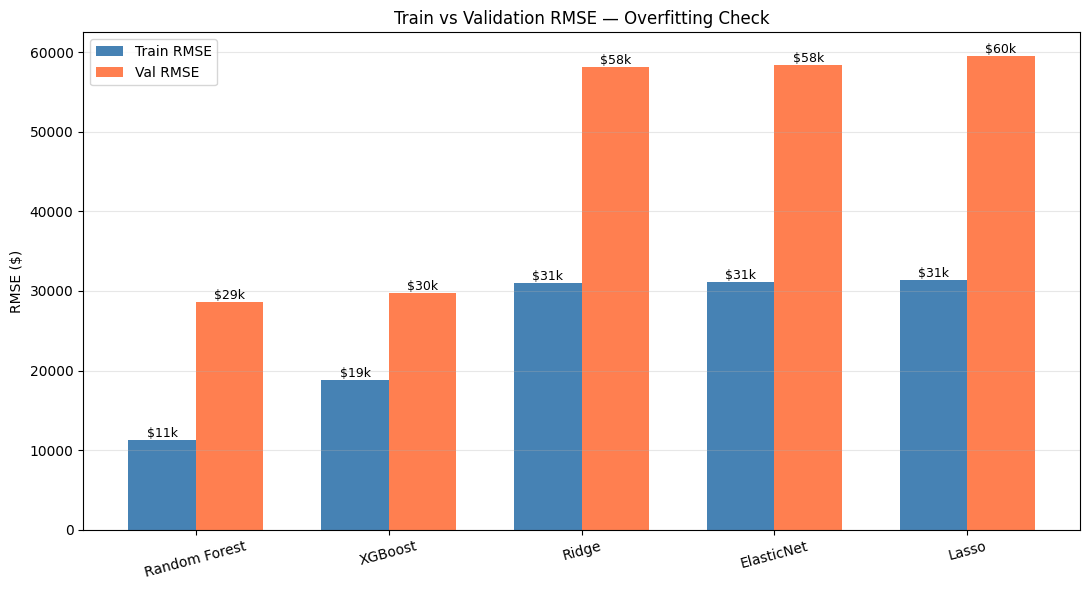

In [35]:
# ── Phase 6 · Load all 5 models & build comparison table ──────────────────────
model_files = {
    'Lasso'        : 'lasso_best.joblib',
    'Ridge'        : 'ridge_best.joblib',
    'ElasticNet'   : 'elasticnet_best.joblib',
    'Random Forest': 'random_forest_best.joblib',
    'XGBoost'      : 'xgboost_best.joblib',
}

results   = []
preds_val = {}     # cache val predictions for residual plots later

for name, fname in model_files.items():
    bundle = joblib.load(MODELS_DIR / fname)
    model  = bundle['model']

    y_pred_train = model.predict(X_train)
    y_pred_val   = model.predict(X_val)
    preds_val[name] = y_pred_val

    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    val_rmse   = np.sqrt(mean_squared_error(y_val,   y_pred_val))
    val_mae    = mean_absolute_error(y_val, y_pred_val)
    val_r2     = r2_score(y_val, y_pred_val)
    gap_pct    = (val_rmse - bundle['cv_rmse']) / bundle['cv_rmse'] * 100   # CV → Val

    results.append({
        'Model':      name,
        'CV RMSE':    bundle['cv_rmse'],
        'Train RMSE': train_rmse,
        'Val RMSE':   val_rmse,
        'Val MAE':    val_mae,
        'Val R²':     val_r2,
        'Gap %':      gap_pct,
    })

results_df = (
    pd.DataFrame(results)
    .sort_values('Val RMSE')
    .reset_index(drop=True)
)

print("Phase 6 — Model Comparison (sorted by Val RMSE):\n")
print(results_df.to_string(index=False, formatters={
    'CV RMSE'   : '${:,.0f}'.format,
    'Train RMSE': '${:,.0f}'.format,
    'Val RMSE'  : '${:,.0f}'.format,
    'Val MAE'   : '${:,.0f}'.format,
    'Val R²'    : '{:.4f}'.format,
    'Gap %'     : '{:+.1f}%'.format,
}))

# ── Side-by-side bar chart: train vs val RMSE (overfitting check) ─────────────
fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(results_df))
w = 0.35

ax.bar(x - w/2, results_df['Train RMSE'], w, label='Train RMSE', color='steelblue')
ax.bar(x + w/2, results_df['Val RMSE'],   w, label='Val RMSE',   color='coral')

for i, (tr, va) in enumerate(zip(results_df['Train RMSE'], results_df['Val RMSE'])):
    ax.text(i - w/2, tr, f'${tr/1000:.0f}k', ha='center', va='bottom', fontsize=9)
    ax.text(i + w/2, va, f'${va/1000:.0f}k', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=15)
ax.set_ylabel('RMSE ($)')
ax.set_title('Train vs Validation RMSE — Overfitting Check')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


Winner by Val RMSE: Random Forest
  CV RMSE     : $28,663
  Train RMSE  : $11,263
  Val  RMSE   : $28,600
  Val  MAE    : $17,185
  Val  R²     :  0.8817
  CV→Val Δ    : -0.2%   (healthy)


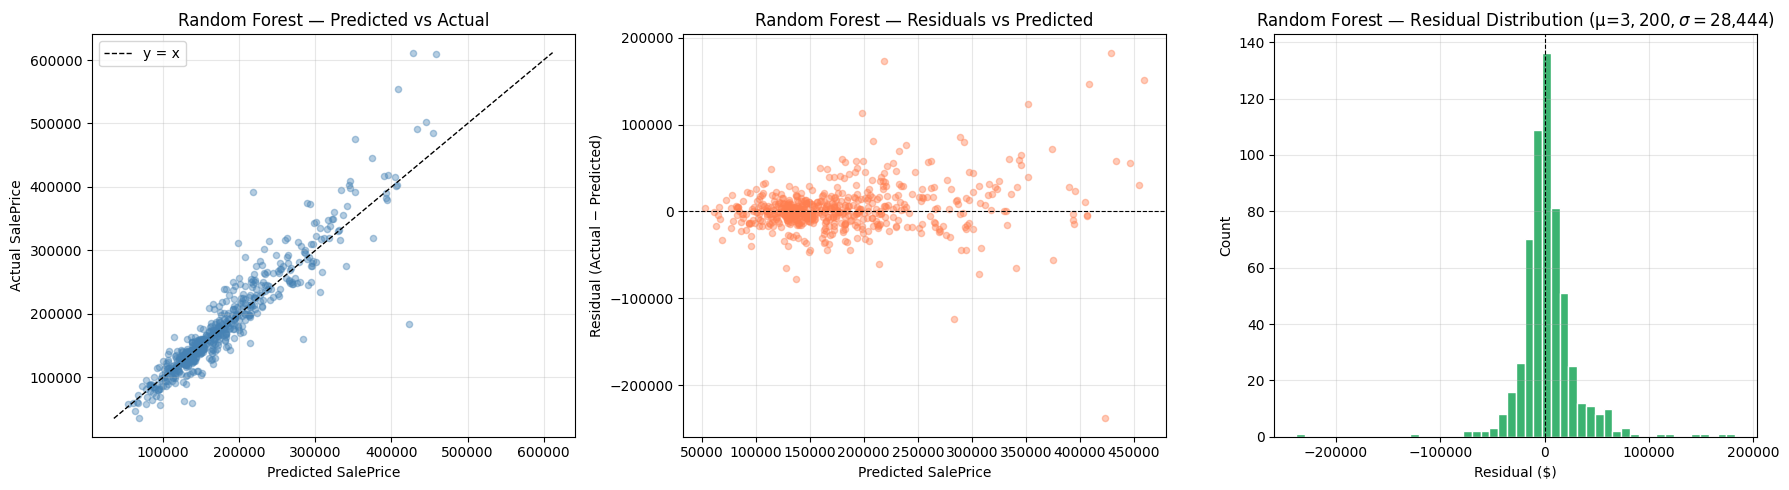


Winner reference saved → WINNER_PATH = ..\models\random_forest_best.joblib


In [36]:
# ── Residual diagnostics for the winning model ────────────────────────────────
winner_row = results_df.iloc[0]
winner     = winner_row['Model']

print(f"Winner by Val RMSE: {winner}")
print(f"  CV RMSE     : ${winner_row['CV RMSE']:,.0f}")
print(f"  Train RMSE  : ${winner_row['Train RMSE']:,.0f}")
print(f"  Val  RMSE   : ${winner_row['Val RMSE']:,.0f}")
print(f"  Val  MAE    : ${winner_row['Val MAE']:,.0f}")
print(f"  Val  R²     :  {winner_row['Val R²']:.4f}")
print(f"  CV→Val Δ    : {winner_row['Gap %']:+.1f}%   "
      f"({'healthy' if abs(winner_row['Gap %']) < 5 else 'investigate'})")

y_pred_w  = preds_val[winner]
residuals = y_val - y_pred_w

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Predicted vs Actual — points should hug the y = x line
axes[0].scatter(y_pred_w, y_val, alpha=0.4, s=20, color='steelblue')
lims = [min(y_val.min(), y_pred_w.min()), max(y_val.max(), y_pred_w.max())]
axes[0].plot(lims, lims, 'k--', linewidth=1, label='y = x')
axes[0].set_xlabel('Predicted SalePrice')
axes[0].set_ylabel('Actual SalePrice')
axes[0].set_title(f'{winner} — Predicted vs Actual')
axes[0].legend()
axes[0].grid(alpha=0.3)

# 2. Residuals vs Predicted — look for funnel shape (heteroscedasticity) or curvature
axes[1].scatter(y_pred_w, residuals, alpha=0.4, s=20, color='coral')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_xlabel('Predicted SalePrice')
axes[1].set_ylabel('Residual (Actual − Predicted)')
axes[1].set_title(f'{winner} — Residuals vs Predicted')
axes[1].grid(alpha=0.3)

# 3. Residual distribution — should look ~Normal, centred on 0
axes[2].hist(residuals, bins=50, edgecolor='white', color='mediumseagreen')
axes[2].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[2].set_xlabel('Residual ($)')
axes[2].set_ylabel('Count')
axes[2].set_title(f'{winner} — Residual Distribution '
                  f'(μ=${residuals.mean():,.0f}, σ=${residuals.std():,.0f})')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Persist the winner reference so Phase 7 (test-set evaluation) can grab it
WINNER_NAME = winner
WINNER_PATH = MODELS_DIR / model_files[winner]
print(f"\nWinner reference saved → WINNER_PATH = {WINNER_PATH}")


## Phase 7 — Final Test Evaluation

The winning model from Phase 6 evaluated on the test set **exactly once**. Touching the test set more than once leaks information and inflates the reported number. Whatever comes out of the cell below is the headline metric for the deliverable.


In [37]:
# ── Phase 7 · Final Test Evaluation (single shot) ─────────────────────────────
# Load the Phase 6 winner from disk — guarantees we're scoring the same artifact
# we'd ship, not a stale in-memory object.
final_bundle = joblib.load(WINNER_PATH)
final_model  = final_bundle['model']

# >>> ONE PREDICTION CALL ON THE TEST SET — DO NOT RE-RUN AFTER TUNING <<<
y_pred_test = final_model.predict(X_test)

test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
test_mae  = mean_absolute_error(y_test, y_pred_test)
test_r2   = r2_score(y_test, y_pred_test)

print("=" * 60)
print(f"  FINAL TEST EVALUATION — {WINNER_NAME}")
print("=" * 60)
print(f"  Test RMSE : ${test_rmse:,.0f}")
print(f"  Test MAE  : ${test_mae:,.0f}")
print(f"  Test R²   :  {test_r2:.4f}")
print("=" * 60)
print()
print(f"DELIVERABLE → Test RMSE: ${test_rmse:,.0f}")

# Persist the final scorecard alongside the model
final_bundle['test_rmse'] = test_rmse
final_bundle['test_mae']  = test_mae
final_bundle['test_r2']   = test_r2
joblib.dump(final_bundle, WINNER_PATH)
print(f"Test metrics appended to → {WINNER_PATH}")


  FINAL TEST EVALUATION — Random Forest
  Test RMSE : $29,408
  Test MAE  : $17,107
  Test R²   :  0.8731

DELIVERABLE → Test RMSE: $29,408
Test metrics appended to → ..\models\random_forest_best.joblib


## Phase 8 — Serialization & Artifacts

Two artifacts go into the deployment Docker image:

1. **`pricing_pipeline.joblib`** — the full sklearn pipeline (preprocessor + Random Forest, with target log-transform built in). Single object, single `.predict()` call returns dollars.
2. **`training_summary.json`** — reference stats for the Stage 2 LLM: target distribution, per-neighborhood medians, and per-feature valid ranges / categories. Used to validate user input and ground LLM explanations in real numbers.


In [38]:
# ── Phase 8 · Save the production inference pipeline ──────────────────────────
ARTIFACTS_DIR = Path('../artifacts')
ARTIFACTS_DIR.mkdir(exist_ok=True)

# Pull the Phase 6 winner (already wrapped: TransformedTargetRegressor →
# Pipeline(preprocessor → model). One .predict() call returns dollars.)
final_pipeline = joblib.load(WINNER_PATH)['model']

pipeline_path = ARTIFACTS_DIR / 'pricing_pipeline.joblib'
joblib.dump(final_pipeline, pipeline_path)

# Smoke test: load from disk and predict on one row to prove the artifact works
loaded     = joblib.load(pipeline_path)
sample_row = X_test.iloc[[0]]
sample_pred = loaded.predict(sample_row)[0]

print(f"Saved pipeline → {pipeline_path.resolve()}")
print(f"Smoke test    : predict(X_test[0]) = ${sample_pred:,.0f}  "
      f"(actual = ${y_test.iloc[0]:,.0f})")


Saved pipeline → C:\Users\saleh\OneDrive\Desktop\AI Real Estate Agent\artifacts\pricing_pipeline.joblib
Smoke test    : predict(X_test[0]) = $184,744  (actual = $195,000)


In [ ]:
# ── Phase 8 · Build training_summary.json for the LLM Stage 2 ─────────────────
import json

# 1. Target distribution
target_stats = {
    'name'  : 'SalePrice',
    'median': float(y_train.median()),
    'mean'  : float(y_train.mean()),
    'iqr'   : [float(y_train.quantile(0.25)), float(y_train.quantile(0.75))],
    'min'   : float(y_train.min()),
    'max'   : float(y_train.max()),
    'std'   : float(y_train.std()),
}

# 2. Per-neighborhood median price (LLM uses this to ground location explanations)
neighborhood_medians = (
    pd.concat([X_train['Neighborhood'], y_train], axis=1)
    .groupby('Neighborhood')['SalePrice']
    .median()
    .sort_values(ascending=False)
    .round(0)
    .astype(int)
    .to_dict()
)

# 3. Per-feature schema — type + valid values/range, for input validation
feature_schema = {'numeric': {}, 'ordinal': {}, 'nominal': {}}

for col in numeric_cols:
    s = X_train[col].dropna()
    feature_schema['numeric'][col] = {
        'min'   : float(s.min()),
        'max'   : float(s.max()),
        'median': float(s.median()),
    }

for col in ordinal_cols:
    feature_schema['ordinal'][col] = {
        'order': qual_order,                       # NA < Po < Fa < TA < Gd < Ex
        'note' : "NA = feature absent (e.g. no basement / no fireplace)",
    }

for col in nominal_cols:
    feature_schema['nominal'][col] = {
        'categories': sorted(X_train[col].dropna().unique().tolist()),
    }

summary = {
    'model'              : 'RandomForestRegressor (5-fold CV tuned)',
    'n_train_samples'    : int(len(X_train)),
    'selected_features'  : SELECTED_FEATURES,
    'target'             : target_stats,
    'neighborhood_medians': neighborhood_medians,
    'features'           : feature_schema,
    'metrics'            : {
        'cv_rmse' : float(joblib.load(WINNER_PATH)['cv_rmse']),
        'val_rmse': float(joblib.load(WINNER_PATH)['val_rmse']),
        'val_r2'  : float(joblib.load(WINNER_PATH)['val_r2']),
        'test_rmse': float(joblib.load(WINNER_PATH)['test_rmse']),
        'test_r2' : float(joblib.load(WINNER_PATH)['test_r2']),
    },
}

summary_path = ARTIFACTS_DIR / 'training_stat.json'
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)

print(f"Saved summary → {summary_path.resolve()}\n")
print("Top 5 most expensive neighborhoods (median SalePrice):")
for nbh, med in list(neighborhood_medians.items())[:5]:
    print(f"  {nbh:<12} ${med:,}")
print(f"\nFeature schema covers {len(numeric_cols)} numeric + "
      f"{len(ordinal_cols)} ordinal + {len(nominal_cols)} nominal columns.")


Saved summary → C:\Users\saleh\OneDrive\Desktop\AI Real Estate Agent\artifacts\training_summary.json

Top 5 most expensive neighborhoods (median SalePrice):
  StoneBr      $334,582
  NridgHt      $317,750
  NoRidge      $290,000
  GrnHill      $280,000
  Veenker      $257,500

Feature schema covers 7 numeric + 4 ordinal + 1 nominal columns.
